# Vision Transformer による BIAS-PROFS データセットの学習

## 1. ライブラリのインポート

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    Trainer,
    TrainingArguments,
    TrainerCallback,
)
import warnings
warnings.filterwarnings("ignore")

# matplotlib日本語文字化け対策
import japanize_matplotlib  # pip install japanize-matplotlib
# もし japanize_matplotlib が使えない場合は以下:
# matplotlib.rcParams['font.family'] = 'IPAexGothic'

# 再現性のためのシード固定
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

E:\ViT-Tutorial\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 設定値

In [2]:
IMAGE_DIR = "../images/bias-profs"
LABEL_CSV = "../labels/bias-profs-labels.csv"
MODEL_NAME = "google/vit-base-patch16-224-in21k"
OUTPUT_DIR = "../models/vit-bias-profs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_CLASSES = 5
CLASS_NAMES = ["A", "B", "C", "D", "E"]
LABEL2ID = {c: i for i, c in enumerate(CLASS_NAMES)}
ID2LABEL = {i: c for i, c in enumerate(CLASS_NAMES)}

# ハイパーパラメータ
LEARNING_RATE = 5e-5
BATCH_SIZE = 16
EPOCHS = 20
WEIGHT_DECAY = 1e-4
N_SPLITS = 5

## 3. ラベルCSVの読み込み

In [3]:
df = pd.read_csv(LABEL_CSV)
print("CSV shape:", df.shape)
print(df.head())

# カラム名を統一(想定: id, class)
df.columns = [c.strip().lower() for c in df.columns]
# id/class カラム自動検出
id_col = [c for c in df.columns if "id" in c][0]
cls_col = [c for c in df.columns if "class" in c][0]

df = df.rename(columns={id_col: "id", cls_col: "label"})
df["label_id"] = df["label"].map(LABEL2ID)

print("\nクラス分布:")
print(df["label"].value_counts().sort_index())

CSV shape: (7716, 2)
   ID Class
0   1     A
1   2     A
2   3     A
3   4     A
4   5     A

クラス分布:
label
A    5302
B     454
C    1929
D      13
E      18
Name: count, dtype: int64


## 4. Dataset 定義

In [4]:
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

class GPCRImageDataset(Dataset):
    def __init__(self, df, image_dir, processor):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{int(row['id'])}.png")
        # グレースケール画像をRGBに変換 (ViTは3チャンネル想定)
        image = Image.open(img_path).convert("RGB")
        encoding = self.processor(images=image, return_tensors="pt")
        pixel_values = encoding["pixel_values"].squeeze(0)
        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(int(row["label_id"]), dtype=torch.long),
        }

## 5. 評価指標の計算関数

In [5]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }

## 6. 学習履歴を取得する Callback

In [6]:
class HistoryCallback(TrainerCallback):
    def __init__(self):
        self.history = {
            "epoch": [],
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "val_precision": [],
            "val_recall": [],
            "val_f1": [],
        }

    def on_epoch_end(self, args, state, control, **kwargs):
        # Trainer.log_history から最新のtrain/evalメトリクスを取得
        train_log = None
        eval_log = None
        for log in reversed(state.log_history):
            if eval_log is None and "eval_loss" in log:
                eval_log = log
            if train_log is None and "loss" in log and "eval_loss" not in log:
                train_log = log
            if train_log and eval_log:
                break

        if eval_log is None:
            return

        epoch = int(round(eval_log.get("epoch", 0)))
        self.history["epoch"].append(epoch)
        self.history["train_loss"].append(train_log["loss"] if train_log else None)
        self.history["train_acc"].append(train_log.get("train_accuracy") if train_log else None)
        self.history["val_loss"].append(eval_log.get("eval_loss"))
        self.history["val_acc"].append(eval_log.get("eval_accuracy"))
        self.history["val_precision"].append(eval_log.get("eval_precision"))
        self.history["val_recall"].append(eval_log.get("eval_recall"))
        self.history["val_f1"].append(eval_log.get("eval_f1_macro"))

        print(
            f"[Epoch {epoch}] "
            f"Train Loss: {train_log['loss']:.4f} | "
            f"Val Loss: {eval_log['eval_loss']:.4f} | "
            f"Val Acc: {eval_log['eval_accuracy']:.4f} | "
            f"Val Precision: {eval_log['eval_precision']:.4f} | "
            f"Val Recall: {eval_log['eval_recall']:.4f} | "
            f"Val Macro F1: {eval_log['eval_f1_macro']:.4f}"
        )

## 7. 学習曲線の描画関数

In [7]:
def plot_learning_curve(history, fold):
    epochs = history["epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(epochs, history["train_loss"], "o-", label="Training Loss")
    axes[0].plot(epochs, history["val_loss"], "s-", label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Fold {fold} - 学習曲線 (Loss)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    train_acc = [a if a is not None else np.nan for a in history["train_acc"]]
    axes[1].plot(epochs, train_acc, "o-", label="Training Accuracy")
    axes[1].plot(epochs, history["val_acc"], "s-", label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"Fold {fold} - 学習曲線 (Accuracy)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, fold, class_names=CLASS_NAMES):
    # 正規化(行ごと)
    cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("予測クラス")
    ax.set_ylabel("正解クラス")
    ax.set_title(f"Fold {fold} - 混同行列(正規化)")

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm_norm[i, j]:.4f}",
                    ha="center", va="center", color=color, fontsize=10)

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 8. 5分割交差検証 学習


Fold 1/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1005.49it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.371325,0.193961,0.952073,0.562416,0.525530,0.541438
2,0.145334,0.151175,0.957902,0.539464,0.566680,0.552170
3,0.090096,0.116520,0.969560,0.765806,0.710170,0.734359
4,0.061306,0.119880,0.971503,0.786539,0.747121,0.764095
5,0.041076,0.164248,0.965674,0.782321,0.751853,0.765940
6,0.032068,0.118089,0.972798,0.707939,0.759908,0.726951
7,0.023807,0.108807,0.975389,0.779832,0.761631,0.769961
8,0.019884,0.113944,0.977979,0.741147,0.769430,0.752846
9,0.014752,0.107592,0.979922,0.778363,0.772312,0.775166
10,0.012086,0.145135,0.974093,0.785476,0.759269,0.771269


[Epoch 1] Train Loss: 0.3713 | Val Loss: 0.1940 | Val Acc: 0.9521 | Val Precision: 0.5624 | Val Recall: 0.5255 | Val Macro F1: 0.5414
[Epoch 2] Train Loss: 0.1453 | Val Loss: 0.1512 | Val Acc: 0.9579 | Val Precision: 0.5395 | Val Recall: 0.5667 | Val Macro F1: 0.5522
[Epoch 3] Train Loss: 0.0901 | Val Loss: 0.1165 | Val Acc: 0.9696 | Val Precision: 0.7658 | Val Recall: 0.7102 | Val Macro F1: 0.7344
[Epoch 4] Train Loss: 0.0613 | Val Loss: 0.1199 | Val Acc: 0.9715 | Val Precision: 0.7865 | Val Recall: 0.7471 | Val Macro F1: 0.7641
[Epoch 5] Train Loss: 0.0411 | Val Loss: 0.1642 | Val Acc: 0.9657 | Val Precision: 0.7823 | Val Recall: 0.7519 | Val Macro F1: 0.7659
[Epoch 6] Train Loss: 0.0321 | Val Loss: 0.1181 | Val Acc: 0.9728 | Val Precision: 0.7079 | Val Recall: 0.7599 | Val Macro F1: 0.7270
[Epoch 7] Train Loss: 0.0238 | Val Loss: 0.1088 | Val Acc: 0.9754 | Val Precision: 0.7798 | Val Recall: 0.7616 | Val Macro F1: 0.7700
[Epoch 8] Train Loss: 0.0199 | Val Loss: 0.1139 | Val Acc: 0.9

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.008288,0.156479,20,0.974093,0.741245,0.762956,0.749368



Fold 1 最終評価結果: {'eval_loss': 0.15647922456264496, 'eval_accuracy': 0.9740932642487047, 'eval_precision': 0.7412446261335839, 'eval_recall': 0.7629562143794001, 'eval_f1_macro': 0.7493675607654173}



Classification Report:
              precision    recall  f1-score   support

           A     0.9796    0.9934    0.9864      1061
           B     0.9634    0.8681    0.9133        91
           C     0.9633    0.9532    0.9582       385
           D     0.0000    0.0000    0.0000         3
           E     0.8000    1.0000    0.8889         4

    accuracy                         0.9741      1544
   macro avg     0.7412    0.7630    0.7494      1544
weighted avg     0.9722    0.9741    0.9729      1544



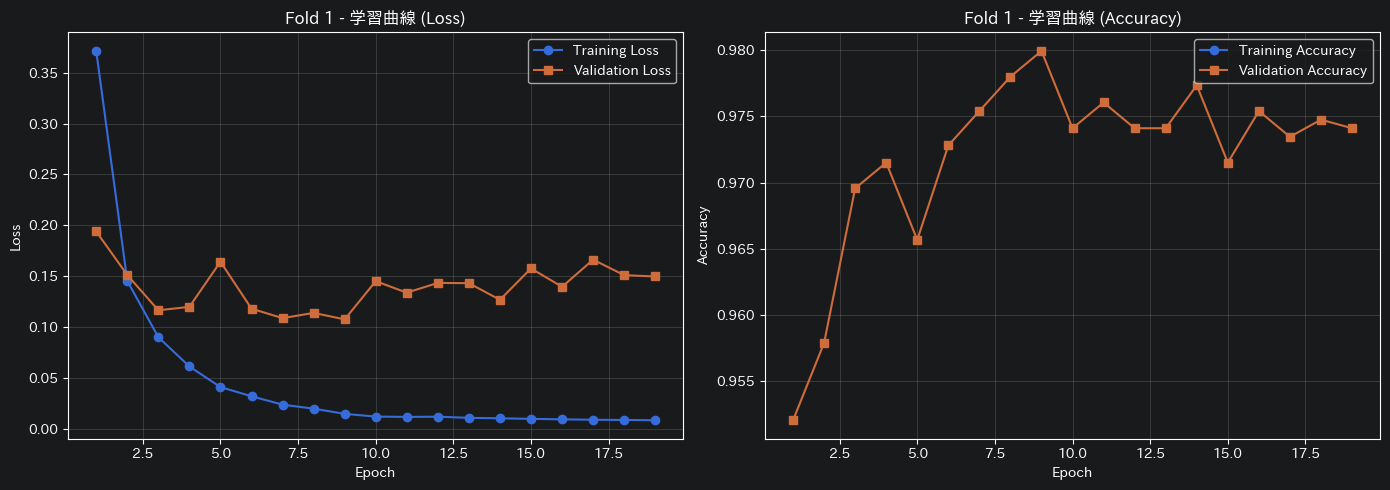

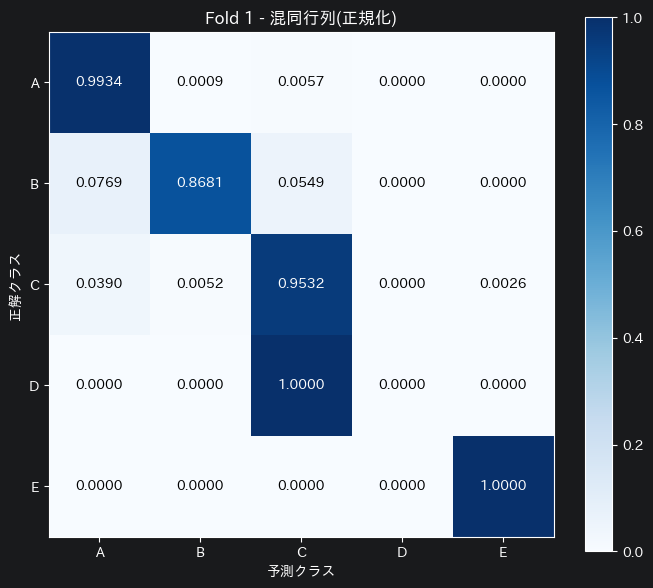


Fold 2/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 991.26it/s] 
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.359929,0.194030,0.946209,0.561932,0.525301,0.538737
2,0.154171,0.140550,0.961763,0.562073,0.553185,0.556988
3,0.090062,0.139383,0.959170,0.773042,0.665162,0.709105
4,0.054301,0.130486,0.966299,0.760537,0.685483,0.716132
5,0.035877,0.155758,0.970188,0.781197,0.675674,0.717839
6,0.037828,0.128205,0.969540,0.843099,0.740260,0.781536
7,0.027634,0.219201,0.958522,0.770723,0.652273,0.696779
8,0.020874,0.166981,0.963707,0.806708,0.804768,0.800558
9,0.017562,0.176609,0.970188,0.879334,0.811709,0.839731
10,0.016422,0.137574,0.974076,0.906869,0.891135,0.898166


[Epoch 1] Train Loss: 0.3599 | Val Loss: 0.1940 | Val Acc: 0.9462 | Val Precision: 0.5619 | Val Recall: 0.5253 | Val Macro F1: 0.5387
[Epoch 2] Train Loss: 0.1542 | Val Loss: 0.1405 | Val Acc: 0.9618 | Val Precision: 0.5621 | Val Recall: 0.5532 | Val Macro F1: 0.5570
[Epoch 3] Train Loss: 0.0901 | Val Loss: 0.1394 | Val Acc: 0.9592 | Val Precision: 0.7730 | Val Recall: 0.6652 | Val Macro F1: 0.7091
[Epoch 4] Train Loss: 0.0543 | Val Loss: 0.1305 | Val Acc: 0.9663 | Val Precision: 0.7605 | Val Recall: 0.6855 | Val Macro F1: 0.7161
[Epoch 5] Train Loss: 0.0359 | Val Loss: 0.1558 | Val Acc: 0.9702 | Val Precision: 0.7812 | Val Recall: 0.6757 | Val Macro F1: 0.7178
[Epoch 6] Train Loss: 0.0378 | Val Loss: 0.1282 | Val Acc: 0.9695 | Val Precision: 0.8431 | Val Recall: 0.7403 | Val Macro F1: 0.7815
[Epoch 7] Train Loss: 0.0276 | Val Loss: 0.2192 | Val Acc: 0.9585 | Val Precision: 0.7707 | Val Recall: 0.6523 | Val Macro F1: 0.6968
[Epoch 8] Train Loss: 0.0209 | Val Loss: 0.1670 | Val Acc: 0.9

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.009043,0.192281,20,0.970836,0.861854,0.884806,0.867992



Fold 2 最終評価結果: {'eval_loss': 0.19228090345859528, 'eval_accuracy': 0.9708360337005832, 'eval_precision': 0.8618535826730701, 'eval_recall': 0.8848063302616392, 'eval_f1_macro': 0.8679924316385016}



Classification Report:
              precision    recall  f1-score   support

           A     0.9868    0.9859    0.9863      1061
           B     0.9730    0.8000    0.8780        90
           C     0.9328    0.9715    0.9518       386
           D     0.6667    0.6667    0.6667         3
           E     0.7500    1.0000    0.8571         3

    accuracy                         0.9708      1543
   macro avg     0.8619    0.8848    0.8680      1543
weighted avg     0.9714    0.9708    0.9705      1543



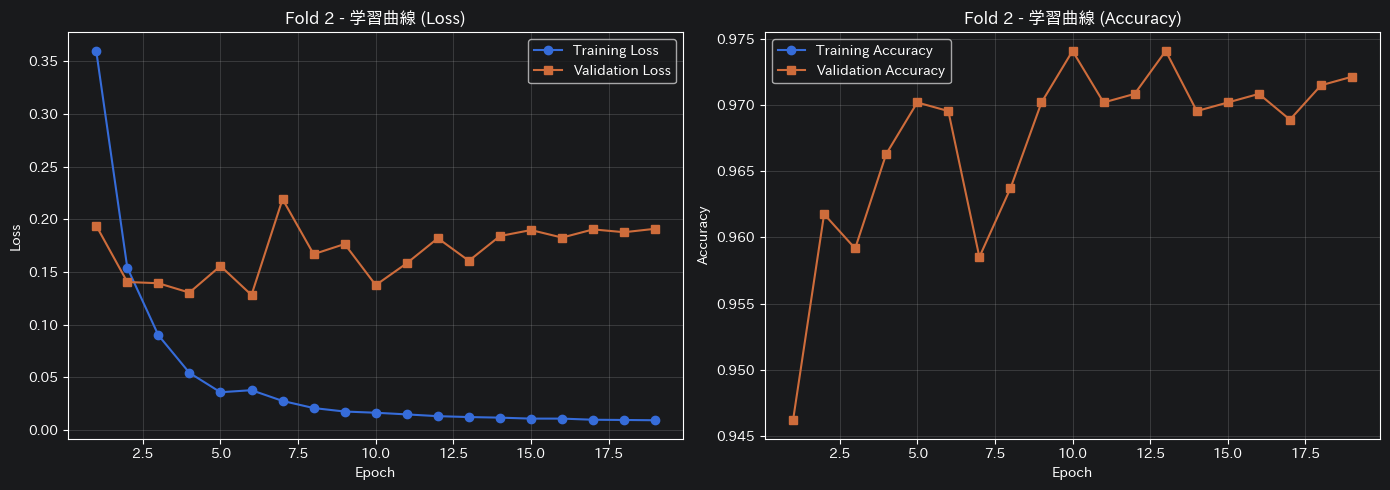

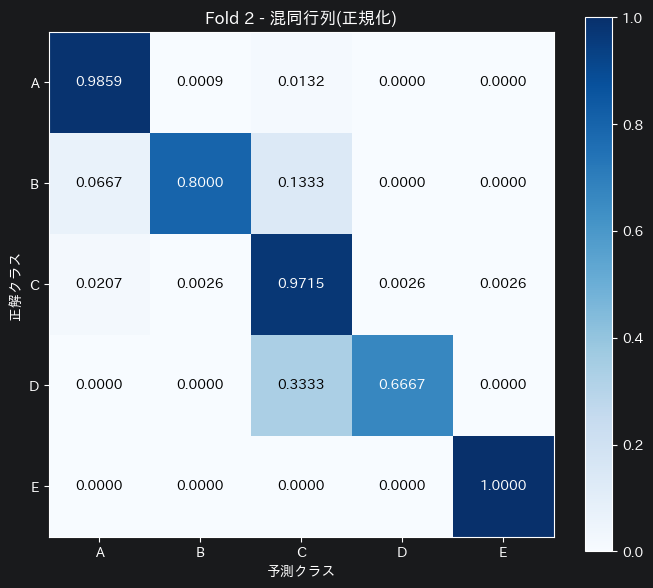


Fold 3/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1056.38it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.357767,0.212891,0.934543,0.531241,0.544588,0.535249
2,0.153876,0.174716,0.950745,0.557032,0.561727,0.558514
3,0.087176,0.172644,0.958522,0.791010,0.761843,0.773041
4,0.054231,0.185244,0.952690,0.724596,0.704436,0.702313
5,0.037450,0.165785,0.964355,0.770126,0.696733,0.726679
6,0.027746,0.180860,0.962411,0.833264,0.767717,0.793463
7,0.025744,0.194224,0.963707,0.773814,0.692132,0.725647
8,0.022298,0.195287,0.964355,0.830972,0.765879,0.791720
9,0.017478,0.208764,0.963059,0.767575,0.699948,0.726719
10,0.013080,0.217178,0.963707,0.773552,0.699839,0.729760


[Epoch 1] Train Loss: 0.3578 | Val Loss: 0.2129 | Val Acc: 0.9345 | Val Precision: 0.5312 | Val Recall: 0.5446 | Val Macro F1: 0.5352
[Epoch 2] Train Loss: 0.1539 | Val Loss: 0.1747 | Val Acc: 0.9507 | Val Precision: 0.5570 | Val Recall: 0.5617 | Val Macro F1: 0.5585
[Epoch 3] Train Loss: 0.0872 | Val Loss: 0.1726 | Val Acc: 0.9585 | Val Precision: 0.7910 | Val Recall: 0.7618 | Val Macro F1: 0.7730
[Epoch 4] Train Loss: 0.0542 | Val Loss: 0.1852 | Val Acc: 0.9527 | Val Precision: 0.7246 | Val Recall: 0.7044 | Val Macro F1: 0.7023
[Epoch 5] Train Loss: 0.0374 | Val Loss: 0.1658 | Val Acc: 0.9644 | Val Precision: 0.7701 | Val Recall: 0.6967 | Val Macro F1: 0.7267
[Epoch 6] Train Loss: 0.0277 | Val Loss: 0.1809 | Val Acc: 0.9624 | Val Precision: 0.8333 | Val Recall: 0.7677 | Val Macro F1: 0.7935
[Epoch 7] Train Loss: 0.0257 | Val Loss: 0.1942 | Val Acc: 0.9637 | Val Precision: 0.7738 | Val Recall: 0.6921 | Val Macro F1: 0.7256
[Epoch 8] Train Loss: 0.0223 | Val Loss: 0.1953 | Val Acc: 0.9

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.007595,0.226947,20,0.966299,0.766660,0.701944,0.727631



Fold 3 最終評価結果: {'eval_loss': 0.22694680094718933, 'eval_accuracy': 0.966299416720674, 'eval_precision': 0.7666604464717672, 'eval_recall': 0.7019440920144802, 'eval_f1_macro': 0.7276305759985977}



Classification Report:
              precision    recall  f1-score   support

           A     0.9802    0.9802    0.9802      1060
           B     0.9121    0.9121    0.9121        91
           C     0.9410    0.9508    0.9459       386
           D     0.0000    0.0000    0.0000         3
           E     1.0000    0.6667    0.8000         3

    accuracy                         0.9663      1543
   macro avg     0.7667    0.7019    0.7276      1543
weighted avg     0.9645    0.9663    0.9653      1543



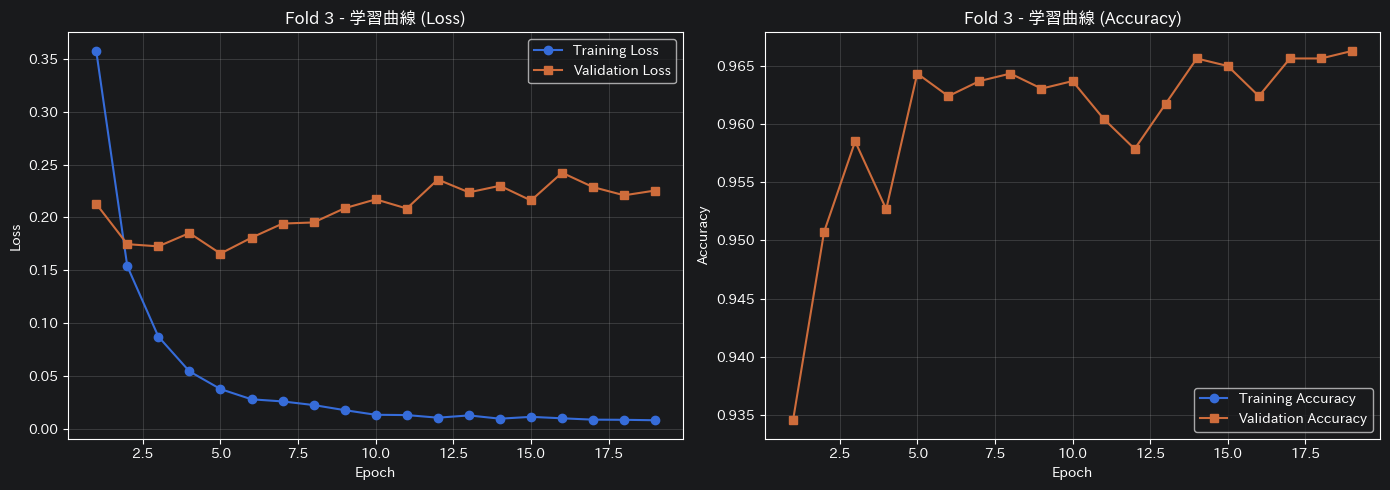

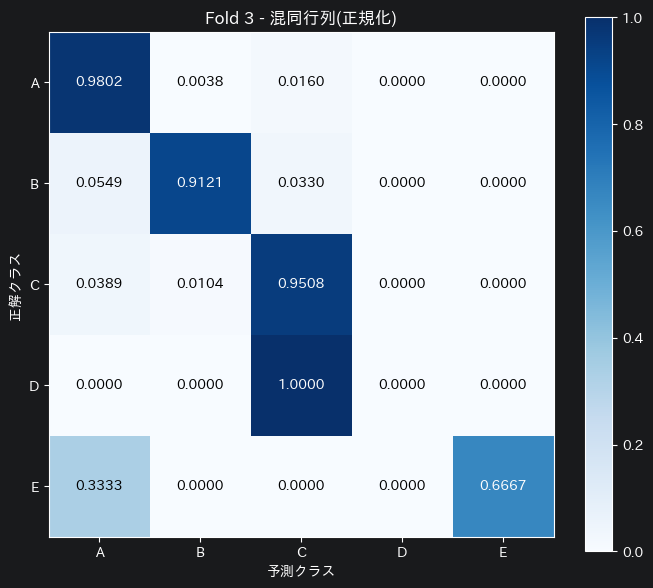


Fold 4/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1458.22it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.355289,0.214160,0.942968,0.527594,0.554489,0.540114
2,0.149237,0.205945,0.944264,0.565408,0.506712,0.529351
3,0.096064,0.139298,0.962411,0.684368,0.658751,0.669100
4,0.056024,0.163615,0.965003,0.758048,0.711294,0.730933
5,0.036785,0.187202,0.963059,0.928427,0.854652,0.871451
6,0.028678,0.160064,0.963707,0.764203,0.756445,0.760233
7,0.024851,0.171926,0.968244,0.769120,0.756712,0.762387
8,0.019127,0.190112,0.964355,0.726995,0.757919,0.739746
9,0.018628,0.175574,0.967596,0.771644,0.757215,0.763930
10,0.014895,0.184500,0.966948,0.762153,0.761703,0.761880


[Epoch 1] Train Loss: 0.3553 | Val Loss: 0.2142 | Val Acc: 0.9430 | Val Precision: 0.5276 | Val Recall: 0.5545 | Val Macro F1: 0.5401
[Epoch 2] Train Loss: 0.1492 | Val Loss: 0.2059 | Val Acc: 0.9443 | Val Precision: 0.5654 | Val Recall: 0.5067 | Val Macro F1: 0.5294
[Epoch 3] Train Loss: 0.0961 | Val Loss: 0.1393 | Val Acc: 0.9624 | Val Precision: 0.6844 | Val Recall: 0.6588 | Val Macro F1: 0.6691
[Epoch 4] Train Loss: 0.0560 | Val Loss: 0.1636 | Val Acc: 0.9650 | Val Precision: 0.7580 | Val Recall: 0.7113 | Val Macro F1: 0.7309
[Epoch 5] Train Loss: 0.0368 | Val Loss: 0.1872 | Val Acc: 0.9631 | Val Precision: 0.9284 | Val Recall: 0.8547 | Val Macro F1: 0.8715
[Epoch 6] Train Loss: 0.0287 | Val Loss: 0.1601 | Val Acc: 0.9637 | Val Precision: 0.7642 | Val Recall: 0.7564 | Val Macro F1: 0.7602
[Epoch 7] Train Loss: 0.0249 | Val Loss: 0.1719 | Val Acc: 0.9682 | Val Precision: 0.7691 | Val Recall: 0.7567 | Val Macro F1: 0.7624
[Epoch 8] Train Loss: 0.0191 | Val Loss: 0.1901 | Val Acc: 0.9

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.007966,0.205579,20,0.967596,0.767717,0.756194,0.761560



Fold 4 最終評価結果: {'eval_loss': 0.20557917654514313, 'eval_accuracy': 0.9675955930006481, 'eval_precision': 0.7677169322250167, 'eval_recall': 0.756194175362227, 'eval_f1_macro': 0.761560101059714}



Classification Report:
              precision    recall  f1-score   support

           A     0.9811    0.9821    0.9816      1060
           B     0.9157    0.8352    0.8736        91
           C     0.9418    0.9637    0.9526       386
           D     0.0000    0.0000    0.0000         2
           E     1.0000    1.0000    1.0000         4

    accuracy                         0.9676      1543
   macro avg     0.7677    0.7562    0.7616      1543
weighted avg     0.9662    0.9676    0.9668      1543



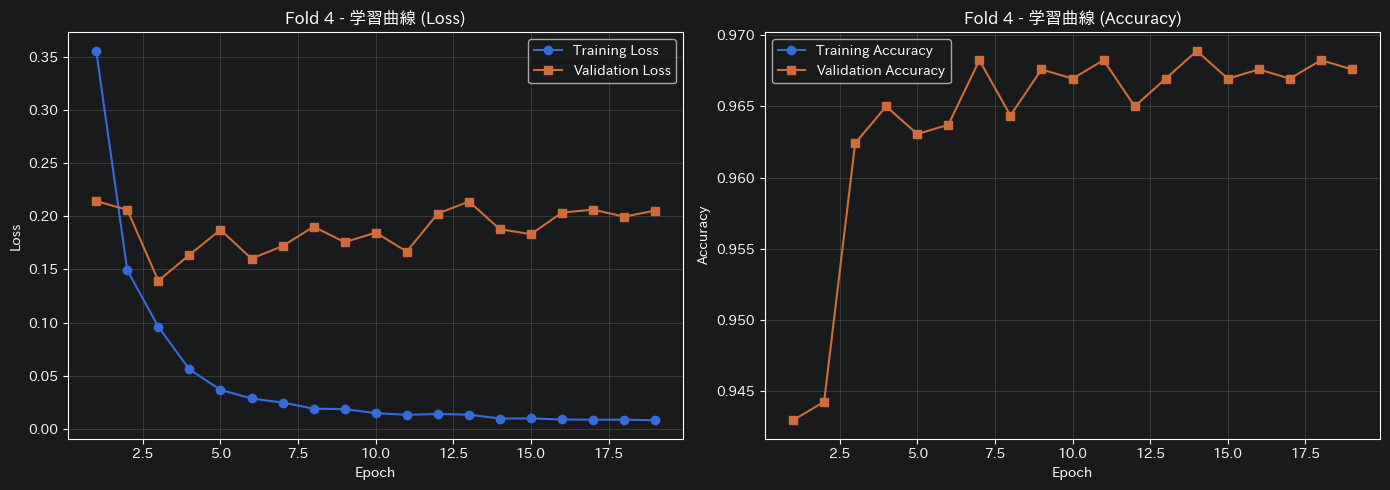

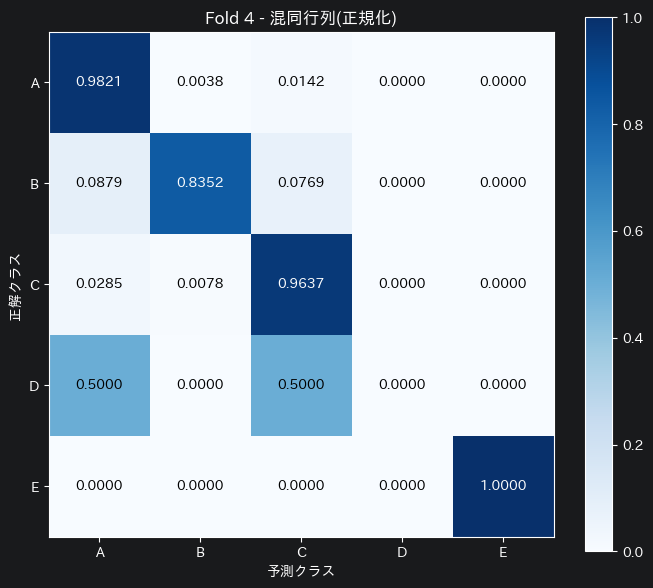


Fold 5/5 開始


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1362.19it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro
1,0.354507,0.177681,0.954634,0.556904,0.539770,0.546692
2,0.152045,0.128282,0.961115,0.561307,0.550055,0.555165
3,0.102320,0.142267,0.958522,0.770770,0.583698,0.628515
4,0.061675,0.164342,0.957226,0.762206,0.755481,0.757682
5,0.040652,0.132439,0.970836,0.775658,0.708644,0.737802
6,0.030300,0.145869,0.965651,0.790110,0.871512,0.817238
7,0.024586,0.147091,0.968892,0.707722,0.718188,0.712611
8,0.023126,0.161534,0.969540,0.768401,0.705269,0.732767
9,0.020026,0.178321,0.965651,0.863872,0.810305,0.833272
10,0.020030,0.161758,0.967596,0.855587,0.875438,0.864912


[Epoch 1] Train Loss: 0.3545 | Val Loss: 0.1777 | Val Acc: 0.9546 | Val Precision: 0.5569 | Val Recall: 0.5398 | Val Macro F1: 0.5467
[Epoch 2] Train Loss: 0.1520 | Val Loss: 0.1283 | Val Acc: 0.9611 | Val Precision: 0.5613 | Val Recall: 0.5501 | Val Macro F1: 0.5552
[Epoch 3] Train Loss: 0.1023 | Val Loss: 0.1423 | Val Acc: 0.9585 | Val Precision: 0.7708 | Val Recall: 0.5837 | Val Macro F1: 0.6285
[Epoch 4] Train Loss: 0.0617 | Val Loss: 0.1643 | Val Acc: 0.9572 | Val Precision: 0.7622 | Val Recall: 0.7555 | Val Macro F1: 0.7577
[Epoch 5] Train Loss: 0.0407 | Val Loss: 0.1324 | Val Acc: 0.9708 | Val Precision: 0.7757 | Val Recall: 0.7086 | Val Macro F1: 0.7378
[Epoch 6] Train Loss: 0.0303 | Val Loss: 0.1459 | Val Acc: 0.9657 | Val Precision: 0.7901 | Val Recall: 0.8715 | Val Macro F1: 0.8172
[Epoch 7] Train Loss: 0.0246 | Val Loss: 0.1471 | Val Acc: 0.9689 | Val Precision: 0.7077 | Val Recall: 0.7182 | Val Macro F1: 0.7126
[Epoch 8] Train Loss: 0.0231 | Val Loss: 0.1615 | Val Acc: 0.9

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1 Macro
0.008171,0.193444,20,0.969540,0.857000,0.869318,0.862845



Fold 5 最終評価結果: {'eval_loss': 0.19344423711299896, 'eval_accuracy': 0.9695398574206092, 'eval_precision': 0.8570002676087093, 'eval_recall': 0.8693175726414557, 'eval_f1_macro': 0.8628445746614366}



Classification Report:
              precision    recall  f1-score   support

           A     0.9858    0.9811    0.9835      1060
           B     0.8384    0.9121    0.8737        91
           C     0.9608    0.9534    0.9571       386
           D     0.5000    0.5000    0.5000         2
           E     1.0000    1.0000    1.0000         4

    accuracy                         0.9695      1543
   macro avg     0.8570    0.8693    0.8628      1543
weighted avg     0.9703    0.9695    0.9698      1543



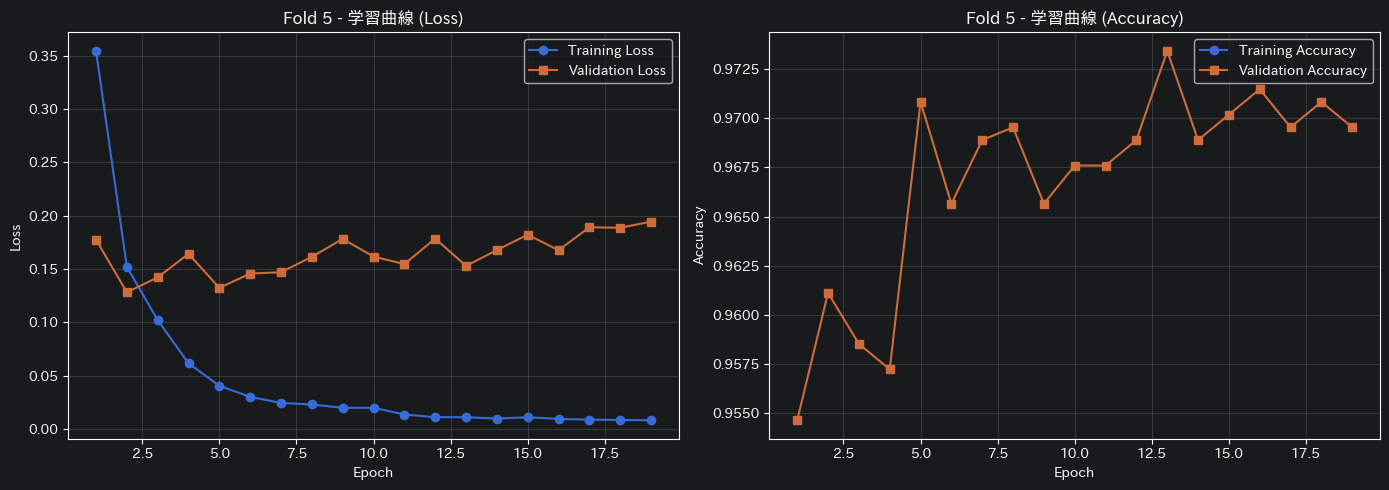

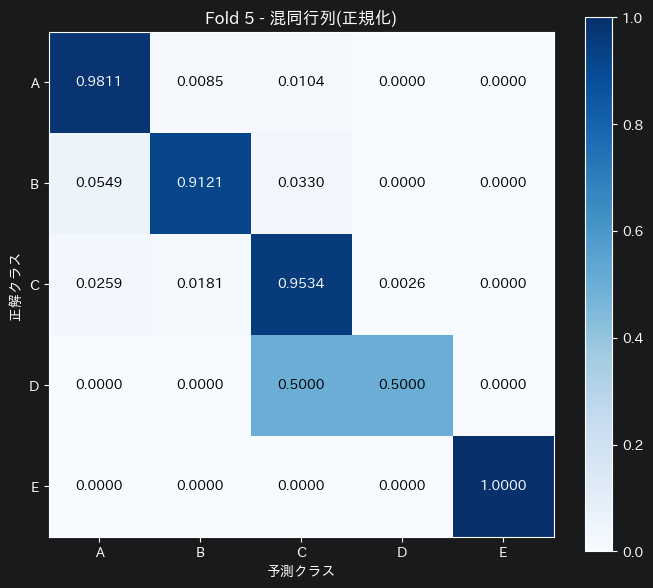

In [8]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []     # 各foldのMacro F1などを保持
fold_histories = []   # 各foldの学習履歴
best_f1 = -1.0
best_fold = -1
best_model_state = None

X = df["id"].values
y = df["label_id"].values

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n{'='*70}")
    print(f"Fold {fold}/{N_SPLITS} 開始")
    print(f"{'='*70}")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    train_dataset = GPCRImageDataset(train_df, IMAGE_DIR, processor)
    val_dataset = GPCRImageDataset(val_df, IMAGE_DIR, processor)

    # モデル初期化(各foldごとに再初期化)
    model = ViTForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_CLASSES,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )

    training_args = TrainingArguments(
        output_dir=os.path.join(OUTPUT_DIR, f"fold_{fold}_checkpoint"),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        fp16=True,
        report_to="none",
        seed=SEED,
        dataloader_num_workers=0,  # Windows では 0 にする
        remove_unused_columns=False,
        load_best_model_at_end=False,
    )

    history_cb = HistoryCallback()

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[history_cb],
    )

    trainer.train()

    # 最終評価
    eval_result = trainer.evaluate()
    print(f"\nFold {fold} 最終評価結果: {eval_result}")

    # 予測 → 混同行列・classification_report
    pred_output = trainer.predict(val_dataset)
    y_pred = np.argmax(pred_output.predictions, axis=-1)
    y_true = pred_output.label_ids

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

    # 学習曲線・混同行列描画
    plot_learning_curve(history_cb.history, fold)
    plot_confusion_matrix(cm, fold)

    macro_f1 = eval_result["eval_f1_macro"]
    fold_results.append({
        "fold": fold,
        "accuracy": eval_result["eval_accuracy"],
        "precision": eval_result["eval_precision"],
        "recall": eval_result["eval_recall"],
        "f1_macro": macro_f1,
    })
    fold_histories.append(history_cb.history)

    # ベストモデル更新
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        best_fold = fold
        best_model_state = {k: v.cpu().clone() for k, v in trainer.model.state_dict().items()}
        best_model_ref = trainer.model

    # メモリ解放
    del trainer, model
    torch.cuda.empty_cache()

## 9. 交差検証の結果

In [9]:
result_df = pd.DataFrame(fold_results)
print("各Foldの結果:")
print(result_df.to_string(index=False))

print("\n平均値:")
print(result_df.drop(columns=["fold"]).mean())
print("\n標準偏差:")
print(result_df.drop(columns=["fold"]).std())

print(f"\nBest Fold: {best_fold} (Macro F1 = {best_f1:.4f})")

各Foldの結果:
 fold  accuracy  precision   recall  f1_macro
    1  0.974093   0.741245 0.762956  0.749368
    2  0.970836   0.861854 0.884806  0.867992
    3  0.966299   0.766660 0.701944  0.727631
    4  0.967596   0.767717 0.756194  0.761560
    5  0.969540   0.857000 0.869318  0.862845

平均値:
accuracy     0.969673
precision    0.798895
recall       0.795044
f1_macro     0.793879
dtype: float64

標準偏差:
accuracy     0.003025
precision    0.056291
recall       0.078709
f1_macro     0.066452
dtype: float64

Best Fold: 2 (Macro F1 = 0.8680)


## 10. Best Model を `.safetensor` 形式で保存

In [10]:
from safetensors.torch import save_file

# ベストモデル復元
best_model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
)
best_model.load_state_dict(best_model_state)

# safetensors形式での保存
save_path = os.path.join(OUTPUT_DIR, "model.safetensors")
# contiguousに変換しておく
state_dict_contig = {k: v.contiguous() for k, v in best_model.state_dict().items()}
save_file(state_dict_contig, save_path)

# 設定ファイル/processorも一緒に保存しておく
best_model.config.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)

# Best foldの情報を記録
with open(os.path.join(OUTPUT_DIR, "best_fold_info.txt"), "w") as f:
    f.write(f"Best Fold: {best_fold}\n")
    f.write(f"Best Macro F1: {best_f1:.4f}\n")
    f.write(f"\n各Foldの結果:\n{result_df.to_string(index=False)}\n")

print(f"ベストモデル(Fold {best_fold}, Macro F1 = {best_f1:.4f})を保存しました:")
print(f"  → {save_path}")

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 42128.15it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ベストモデル(Fold 2, Macro F1 = 0.8680)を保存しました:
  → ../models/vit-bias-profs\model.safetensors
